# electrolysis cement NPV simulation

Run the electrolysis cement Monte Carlo simulation and visualize the resulting NPV distribution.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_technology_npv,
)


In [2]:
TECHNOLOGY = 'electrolysis'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_cement_technology_npv(
    technology=TECHNOLOGY,
    size=SAMPLE_SIZE,
    rng=rng,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,electricity_consumption_mwh_per_t,...,annual_variable_opex_eur,annual_fuel_cost_eur,annual_electricity_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_t,npv_eur_per_t,npv_million_eur_per_t,coal_price_eur_per_mwh_th
0,0,electrolysis,absolute,not_applicable,1000000.0,435.473051,45.703097,19.027748,0.0,2.318995,...,1.902775e+07,0.0,4.165106e+08,7.357962e+06,-3.385995e+08,-4.049946e+09,25000000.0,-161.997857,-0.000162,13.578016
1,1,electrolysis,absolute,not_applicable,1000000.0,372.434878,46.096799,18.938098,0.0,2.217126,...,1.893810e+07,0.0,3.613157e+08,1.049847e+07,-2.868491e+08,-3.434485e+09,25000000.0,-137.379386,-0.000137,9.132512
2,2,electrolysis,absolute,not_applicable,1000000.0,458.373166,36.406411,23.778772,0.0,2.749966,...,2.377877e+07,0.0,2.500472e+08,7.918020e+06,-1.681504e+08,-2.253341e+09,25000000.0,-90.133659,-0.000090,11.974056
3,3,electrolysis,absolute,not_applicable,1000000.0,418.269267,32.230038,20.448712,0.0,2.711001,...,2.044871e+07,0.0,5.530860e+08,9.449050e+06,-4.652138e+08,-5.384322e+09,25000000.0,-215.372888,-0.000215,10.982182
4,4,electrolysis,absolute,not_applicable,1000000.0,309.058516,40.061504,22.307259,0.0,2.723218,...,2.230726e+07,0.0,4.838233e+08,7.346135e+06,-4.035382e+08,-4.616738e+09,25000000.0,-184.669537,-0.000185,11.398602


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_t = results["npv_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/t"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/t
count,100000.000000,100000.000000
mean,-4080.848862,-163.233954
std,1252.892865,50.115715
min,-7978.706511,-319.148260
5%,-6287.008847,-251.480354
50%,-3984.435594,-159.377424
95%,-2157.296172,-86.291847
max,-787.248841,-31.489954


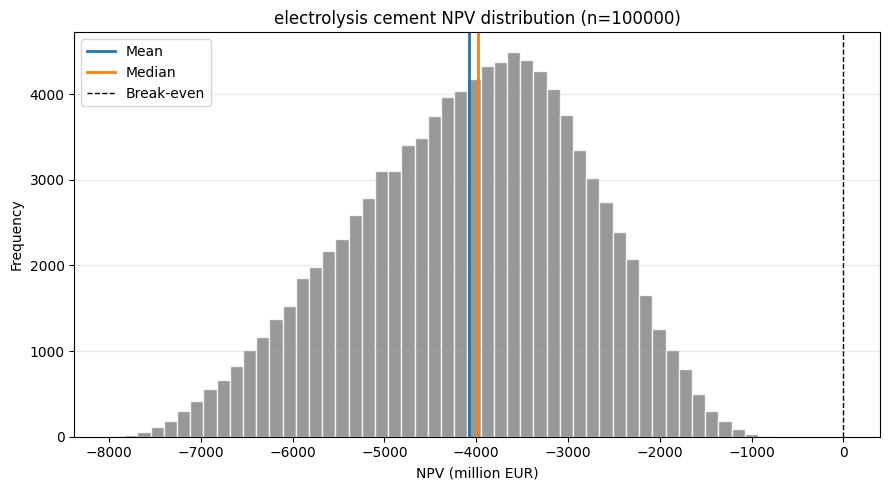

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrolysis cement NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


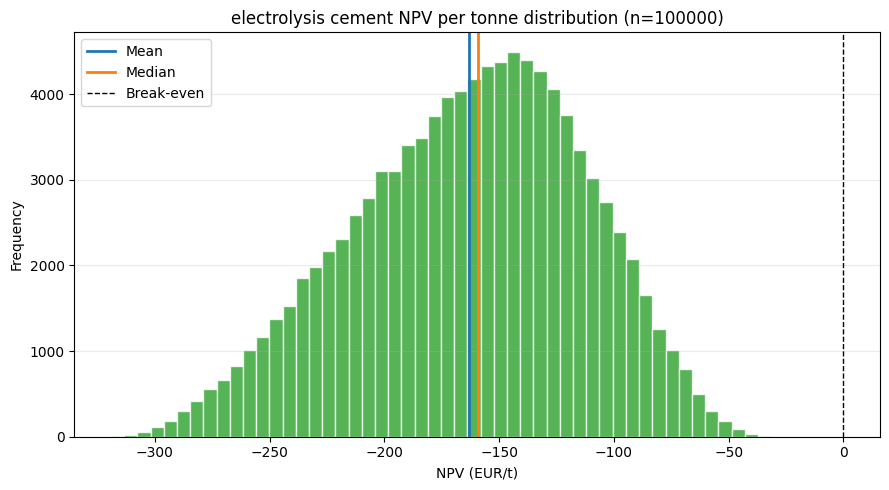

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrolysis cement NPV per tonne distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/t)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           36.325425
annual_variable_opex_eur        20.004659
annual_fuel_cost_eur             0.000000
annual_electricity_cost_eur    431.677851
annual_emissions_cost_eur        7.986549
annual_net_cash_flow_eur      -345.994484
Name: Mean annual value, million EUR, dtype: float64